# Finlora Finance Flow — Exploratory Data Analysis

This notebook performs a structured exploratory analysis of the cleaned Finlora transaction and account datasets.

**Analysis flow:** data loading → data validation → dataset joining → target/class-imbalance analysis → univariate analysis → fraud segmentation → numerical distributions → temporal patterns → cross-border/device analysis → relationships between key risk variables → EDA findings.

The transaction dataset remains the main dataset throughout the analysis.

In [126]:
# Import libraries required for data loading, analysis, and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

In [127]:
# Load the cleaned datasets from the processed_data folder
transactions = pd.read_csv("../data/processed_data/finlora_transactions_clean.csv")
accounts = pd.read_csv("../data/processed_data/finlora_accounts_clean.csv")

print("Transactions shape:", transactions.shape)
print("Accounts shape:", accounts.shape)

Transactions shape: (126000, 25)
Accounts shape: (7200, 8)


In [128]:
# Convert date and time columns to datetime format for time-based EDA
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"], errors="coerce")
accounts["account_created_date"] = pd.to_datetime(
    accounts["account_created_date"], errors="coerce"
)

In [129]:
# Display the first five records from both datasets
display(transactions.head())
display(accounts.head())

,transaction_id,account_id,account_type,kyc_tier,timestamp,day_of_week,hour_of_day,description,merchant_name,merchant_category,...,transaction_velocity_1h,transaction_country,home_country,is_cross_border,device_id,is_new_device,account_age_days,status,is_fraud,negative_avg_flag
0,FLR250216186265,FLR-ACC-100000,individual,tier3_enhanced,2025-02-16 14:55:35,Sunday,14,CNP PURCHASE - BOLT,Bolt,travel,...,0,NG,NG,0,Unknown,-1.0,903,Completed,0,0
1,FLR250423143305,FLR-ACC-100000,individual,tier3_enhanced,2025-04-23 13:35:40,Wednesday,13,WEB PURCHASE - SLACK,Slack,subscription/saas,...,0,NG,NG,0,Unknown,-1.0,969,Declined,0,0
2,FLR250424154897,FLR-ACC-100000,individual,tier3_enhanced,2025-04-24 12:30:34,Thursday,12,MOBILE PURCHASE - JUSTRITE SUPERSTORE,Justrite Superstore,groceries,...,0,NG,NG,0,DEV-9055235108,0.0,970,Completed,0,0
3,FLR250428101772,FLR-ACC-100000,individual,tier3_enhanced,2025-04-28 14:41:59,Monday,14,CNP PURCHASE - ADOBE CREATIVE CLOUD,Adobe Creative Cloud,subscription/saas,...,0,NG,NG,0,Unknown,-1.0,974,Completed,0,0
4,FLR250628102827,FLR-ACC-100000,individual,tier3_enhanced,2025-06-28 16:15:47,Saturday,16,MOBILE PURCHASE - APPLE STORE,Apple Store,electronics,...,0,NG,NG,0,DEV-9055235108,0.0,1035,Declined,0,0


,account_id,account_holder_name,account_type,home_country,currency,kyc_tier,account_created_date,personal_spend_baseline_usd
0,FLR-ACC-100000,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23
1,FLR-ACC-100001,Bluewave Foods Ltd,Business,NG,NGN,Tier1_Basic,2026-04-27,810.68
2,FLR-ACC-100002,Global Trading LLC,Business,US,USD,Tier2_Verified,2026-03-29,433.67
3,FLR-ACC-100003,Femi Adeyemi,Individual,NG,NGN,Tier3_Enhanced,2025-09-15,19.18
4,FLR-ACC-100004,Ngozi Brown,Individual,NG,NGN,Tier3_Enhanced,2024-06-18,28.68


In [130]:
# Check the structure and data types of the transaction dataset
transactions.info()

print("\nAccount dataset information:")
accounts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126000 entries, 0 to 125999
Data columns (total 25 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   transaction_id              126000 non-null  object        
 1   account_id                  126000 non-null  object        
 2   account_type                126000 non-null  object        
 3   kyc_tier                    126000 non-null  object        
 4   timestamp                   126000 non-null  datetime64[ns]
 5   day_of_week                 126000 non-null  object        
 6   hour_of_day                 126000 non-null  int64         
 7   description                 126000 non-null  object        
 8   merchant_name               126000 non-null  object        
 9   merchant_category           126000 non-null  object        
 10  channel                     126000 non-null  object        
 11  amount                      126000 non-

In [131]:
# Check missing values before joining the datasets
print("Transaction missing values:")
display(transactions.isna().sum())

print("\nAccount missing values:")
display(accounts.isna().sum())

Transaction missing values:


transaction_id                0
account_id                    0
account_type                  0
kyc_tier                      0
timestamp                     0
day_of_week                   0
hour_of_day                   0
description                   0
merchant_name                 0
merchant_category             0
channel                       0
amount                        0
currency                      0
amount_to_avg_ratio           0
avg_transaction_amount_30d    0
transaction_velocity_1h       0
transaction_country           0
home_country                  0
is_cross_border               0
device_id                     0
is_new_device                 0
account_age_days              0
status                        0
is_fraud                      0
negative_avg_flag             0
dtype: int64


Account missing values:


account_id                     0
account_holder_name            0
account_type                   0
home_country                   0
currency                       0
kyc_tier                       0
account_created_date           0
personal_spend_baseline_usd    0
dtype: int64

In [132]:
# Check for duplicate rows in both datasets
print("Transaction duplicate rows:", transactions.duplicated().sum())
print("Account duplicate rows:", accounts.duplicated().sum())

Transaction duplicate rows: 0
Account duplicate rows: 0


In [133]:
# Confirm that account_id is available in both datasets before joining
print("account_id in transactions:", "account_id" in transactions.columns)
print("account_id in accounts:", "account_id" in accounts.columns)

account_id in transactions: True
account_id in accounts: True


In [134]:
# Check that each account_id appears only once in the account dataset
print("Unique account IDs:", accounts["account_id"].nunique())
print("Account rows:", len(accounts))

Unique account IDs: 7200
Account rows: 7200


In [135]:
# Join account information to the transaction dataset while keeping every transaction
df = transactions.merge(
    accounts,
    on="account_id",
    how="left",
    validate="many_to_one"
)

print("Joined dataset shape:", df.shape)

Joined dataset shape: (126000, 32)


In [136]:
# Check the joined dataset for missing values and duplicates
print("Total missing values after join:", df.isna().sum().sum())
print("Duplicate rows after join:", df.duplicated().sum())

Total missing values after join: 0
Duplicate rows after join: 0


In [137]:
# Check the final structure of the joined dataset
display(df.head())
print("Rows:", len(df))
print("Columns:", df.shape[1])

,transaction_id,account_id,account_type_x,kyc_tier_x,timestamp,day_of_week,hour_of_day,description,merchant_name,merchant_category,...,status,is_fraud,negative_avg_flag,account_holder_name,account_type_y,home_country_y,currency_y,kyc_tier_y,account_created_date,personal_spend_baseline_usd
0,FLR250216186265,FLR-ACC-100000,individual,tier3_enhanced,2025-02-16 14:55:35,Sunday,14,CNP PURCHASE - BOLT,Bolt,travel,...,Completed,0,0,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23
1,FLR250423143305,FLR-ACC-100000,individual,tier3_enhanced,2025-04-23 13:35:40,Wednesday,13,WEB PURCHASE - SLACK,Slack,subscription/saas,...,Declined,0,0,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23
2,FLR250424154897,FLR-ACC-100000,individual,tier3_enhanced,2025-04-24 12:30:34,Thursday,12,MOBILE PURCHASE - JUSTRITE SUPERSTORE,Justrite Superstore,groceries,...,Completed,0,0,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23
3,FLR250428101772,FLR-ACC-100000,individual,tier3_enhanced,2025-04-28 14:41:59,Monday,14,CNP PURCHASE - ADOBE CREATIVE CLOUD,Adobe Creative Cloud,subscription/saas,...,Completed,0,0,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23
4,FLR250628102827,FLR-ACC-100000,individual,tier3_enhanced,2025-06-28 16:15:47,Saturday,16,MOBILE PURCHASE - APPLE STORE,Apple Store,electronics,...,Declined,0,0,Amaka Okafor,Individual,NG,NGN,Tier3_Enhanced,2022-08-28,63.23


Rows: 126000
Columns: 32


## 1. Target Variable and Fraud Class Distribution

Fraud detection is an imbalanced classification problem, so the proportion of fraudulent transactions should be established before examining individual risk factors.

In [138]:
# Analyse the distribution of fraudulent and non-fraudulent transactions
fraud_counts = df["is_fraud"].value_counts().sort_index()
display(fraud_counts)

print("Overall fraud rate: {:.2f}%".format(df["is_fraud"].mean() * 100))

is_fraud
0    122648
1      3352
Name: count, dtype: int64

Overall fraud rate: 2.66%


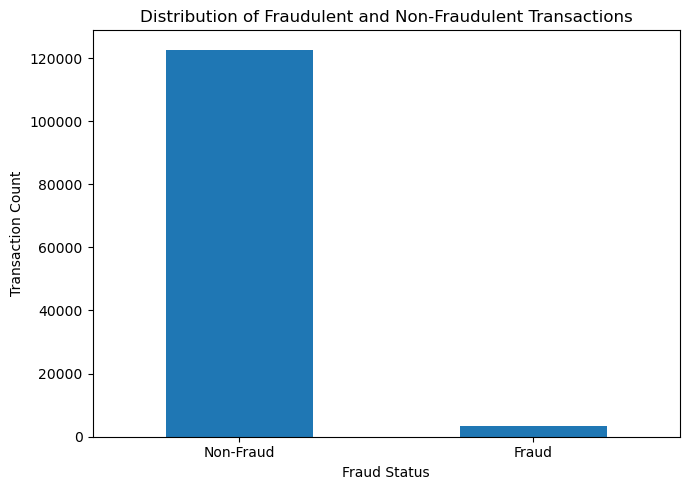

In [139]:
# Visualise the fraud class distribution
fraud_counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Fraud Status")
plt.ylabel("Transaction Count")
plt.title("Distribution of Fraudulent and Non-Fraudulent Transactions")
plt.xticks([0, 1], ["Non-Fraud", "Fraud"], rotation=0)
plt.tight_layout()
plt.show()

## 2. Transaction Amount Analysis

Transaction amount is a central numerical variable for fraud-risk analysis. Because financial transaction amounts can be highly skewed, both summary statistics and a distribution plot are examined.

In [140]:
# Generate descriptive statistics for key numerical transaction variables
display(
    df[
        [
            "amount",
            "amount_to_avg_ratio",
            "avg_transaction_amount_30d",
            "transaction_velocity_1h",
            "account_age_days",
            "personal_spend_baseline_usd"
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
amount,126000.0,796491.817660,4.054387e+06,-1834602.45,63.1050,5942.24,120847.0375,2.691614e+08
amount_to_avg_ratio,126000.0,7.921400,1.535667e+02,0.00,0.2500,0.98,1.8300,3.176269e+04
avg_transaction_amount_30d,126000.0,767599.456062,3.290377e+06,-1669153.21,92.4275,5942.24,157570.0975,1.733621e+08
transaction_velocity_1h,126000.0,0.011429,1.103226e-01,0.00,0.0000,0.00,0.0000,3.000000e+00
account_age_days,126000.0,354.721992,3.313270e+02,0.00,35.0000,289.00,577.0000,1.682000e+03
personal_spend_baseline_usd,126000.0,292.277286,6.315042e+02,3.77,44.5100,92.19,296.2300,1.046965e+04


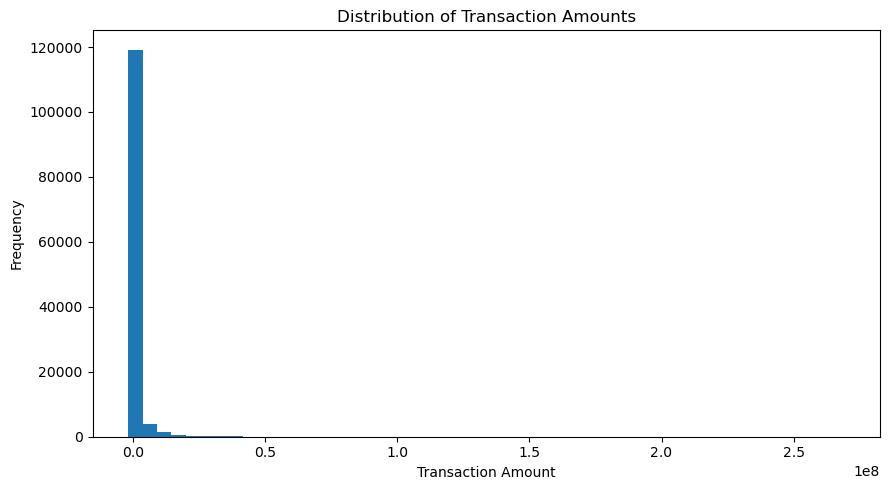

In [141]:
# Visualise the transaction amount distribution
plt.figure(figsize=(9, 5))
plt.hist(df["amount"], bins=50)
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amounts")
plt.tight_layout()
plt.show()

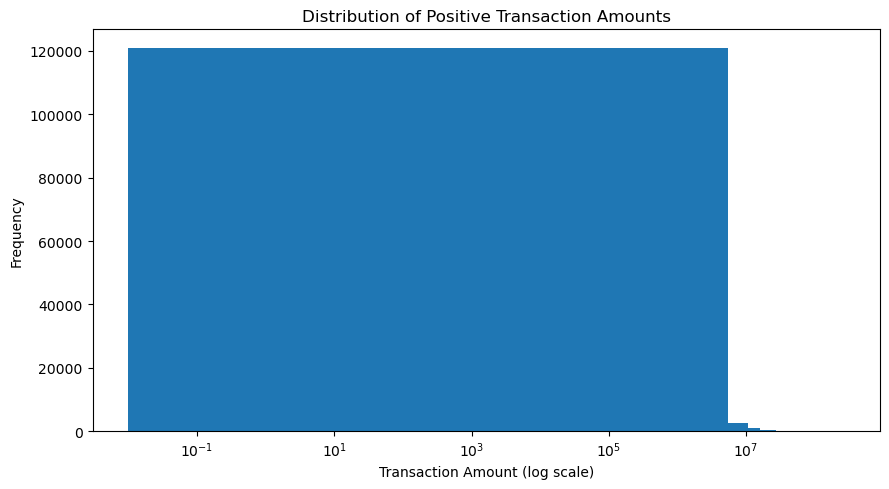

In [142]:
# Use a logarithmic x-axis to make the distribution of highly variable transaction amounts easier to inspect
positive_amounts = df.loc[df["amount"] > 0, "amount"]

plt.figure(figsize=(9, 5))
plt.hist(positive_amounts, bins=50)
plt.xscale("log")
plt.xlabel("Transaction Amount (log scale)")
plt.ylabel("Frequency")
plt.title("Distribution of Positive Transaction Amounts")
plt.tight_layout()
plt.show()

## 3. Fraud by Device Status

Device status is coded as:
- `0` = Existing Device
- `1` = New Device
- `-1` = Unknown Device

In [143]:
# Analyse fraud according to device status: existing, new, or unknown
device_analysis = (
    df.groupby("is_new_device")["is_fraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

device_analysis["fraud_rate_%"] = (
    device_analysis["fraud_rate"] * 100
).round(2)

device_analysis.index = device_analysis.index.map({
    0: "Existing Device",
    1: "New Device",
    -1: "Unknown Device"
})

display(device_analysis)

,transaction_count,fraud_count,fraud_rate,fraud_rate_%
is_new_device,,,,
Unknown Device,14334,343,0.023929,2.39
Existing Device,107771,2781,0.025805,2.58
New Device,3895,228,0.058537,5.85


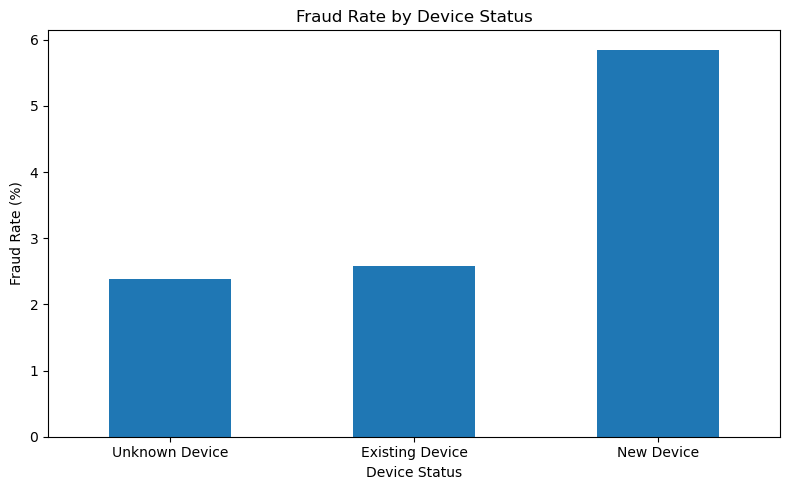

In [144]:
# Visualise fraud rate by device status
device_analysis["fraud_rate_%"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Device Status")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Device Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Fraud by KYC Tier

In [145]:
# Analyse fraud rate by KYC tier
kyc_analysis = (
    df.groupby("kyc_tier")["is_fraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

kyc_analysis["fraud_rate_%"] = (
    kyc_analysis["fraud_rate"] * 100
).round(2)

display(kyc_analysis.sort_values("fraud_rate_%", ascending=False))

KeyError: 'kyc_tier'

In [ ]:
# Visualise fraud rate by KYC tier
kyc_analysis["fraud_rate_%"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("KYC Tier")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by KYC Tier")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Fraud by Account Type

In [ ]:
# Analyse fraud rate by account type
account_type_analysis = (
    df.groupby("account_type")["is_fraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

account_type_analysis["fraud_rate_%"] = (
    account_type_analysis["fraud_rate"] * 100
).round(2)

display(account_type_analysis.sort_values("fraud_rate_%", ascending=False))

In [ ]:
# Visualise fraud rate by account type
account_type_analysis["fraud_rate_%"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Account Type")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Account Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Fraud by Transaction Channel

In [ ]:
# Analyse fraud rate by transaction channel
channel_analysis = (
    df.groupby("channel")["is_fraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

channel_analysis["fraud_rate_%"] = (
    channel_analysis["fraud_rate"] * 100
).round(2)

display(channel_analysis.sort_values("fraud_rate_%", ascending=False))

In [ ]:
# Visualise fraud rate by transaction channel
channel_analysis["fraud_rate_%"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Transaction Channel")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Channel")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7. Fraud by Merchant Category

In [ ]:
# Analyse fraud rate by merchant category
merchant_analysis = (
    df.groupby("merchant_category")["is_fraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

merchant_analysis["fraud_rate_%"] = (
    merchant_analysis["fraud_rate"] * 100
).round(2)

display(merchant_analysis.sort_values("fraud_rate_%", ascending=False))

In [ ]:
# Visualise fraud rate by merchant category
merchant_analysis["fraud_rate_%"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(11, 6)
)

plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Merchant Category")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## 8. Fraud by Transaction Status

In [ ]:
# Analyse fraud rate by transaction status
status_analysis = (
    df.groupby("status")["is_fraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

status_analysis["fraud_rate_%"] = (
    status_analysis["fraud_rate"] * 100
).round(2)

display(status_analysis.sort_values("fraud_rate_%", ascending=False))

In [ ]:
# Visualise fraud rate by transaction status
status_analysis["fraud_rate_%"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Transaction Status")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Cross-Border Fraud Analysis

In [ ]:
# Analyse fraud according to whether the transaction was cross-border
cross_border_analysis = (
    df.groupby("is_cross_border")["is_fraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

cross_border_analysis["fraud_rate_%"] = (
    cross_border_analysis["fraud_rate"] * 100
).round(2)

cross_border_analysis.index = cross_border_analysis.index.map({
    0: "Domestic",
    1: "Cross-Border"
})

display(cross_border_analysis)

In [ ]:
# Visualise fraud rate by cross-border status
cross_border_analysis["fraud_rate_%"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate: Domestic vs Cross-Border Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Fraud by Transaction Country

This analysis identifies countries with sufficient transaction activity and compares their observed fraud rates.

In [ ]:
# Analyse fraud rate by transaction country
country_analysis = (
    df.groupby("transaction_country")["is_fraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

country_analysis["fraud_rate_%"] = (
    country_analysis["fraud_rate"] * 100
).round(2)

# Focus on countries with at least 100 transactions to avoid unstable rates from very small groups
country_analysis_filtered = country_analysis[
    country_analysis["transaction_count"] >= 100
].sort_values("fraud_rate_%", ascending=False)

display(country_analysis_filtered.head(15))

In [ ]:
# Visualise the 15 highest observed country-level fraud rates among countries with sufficient transaction volume
country_analysis_filtered.head(15)["fraud_rate_%"].sort_values().plot(
    kind="barh",
    figsize=(9, 7)
)

plt.xlabel("Fraud Rate (%)")
plt.ylabel("Transaction Country")
plt.title("Highest Fraud Rates by Transaction Country")
plt.tight_layout()
plt.show()

## 11. Fraud by Hour of Day

In [ ]:
# Analyse fraud rate by hour of day
hour_analysis = (
    df.groupby("hour_of_day")["is_fraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

hour_analysis["fraud_rate_%"] = (
    hour_analysis["fraud_rate"] * 100
).round(2)

display(hour_analysis)

In [ ]:
# Visualise hourly fraud rate
plt.figure(figsize=(10, 5))
plt.plot(hour_analysis.index, hour_analysis["fraud_rate_%"], marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Hour of Day")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Fraud by Day of Week

In [ ]:
# Analyse fraud rate by day of week
day_analysis = (
    df.groupby("day_of_week")["is_fraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

day_analysis["fraud_rate_%"] = (
    day_analysis["fraud_rate"] * 100
).round(2)

display(day_analysis)

In [ ]:
# Visualise fraud rate by day of week
day_analysis["fraud_rate_%"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Day of Week")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 13. Transaction Velocity and Fraud

Transaction velocity is an important behavioural feature because unusually frequent activity may provide a useful fraud signal.

In [ ]:
# Compare transaction velocity between fraudulent and non-fraudulent transactions
velocity_summary = (
    df.groupby("is_fraud")["transaction_velocity_1h"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(velocity_summary)

In [ ]:
# Visualise transaction velocity for fraud and non-fraud transactions
df.boxplot(
    column="transaction_velocity_1h",
    by="is_fraud",
    figsize=(8, 5)
)

plt.suptitle("")
plt.title("Transaction Velocity by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Transactions in 1 Hour")
plt.xticks([1, 2], ["Non-Fraud", "Fraud"])
plt.tight_layout()
plt.show()

## 14. Amount-to-Average Ratio and Fraud

The `amount_to_avg_ratio` compares a transaction amount with the account's average transaction amount and can help identify transactions that differ substantially from normal behaviour.

In [ ]:
# Compare amount-to-average ratio between fraudulent and non-fraudulent transactions
ratio_summary = (
    df.groupby("is_fraud")["amount_to_avg_ratio"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(ratio_summary)

In [ ]:
# Visualise amount-to-average ratio by fraud status
df.boxplot(
    column="amount_to_avg_ratio",
    by="is_fraud",
    figsize=(8, 5)
)

plt.suptitle("")
plt.title("Amount-to-Average Ratio by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Amount-to-Average Ratio")
plt.xticks([1, 2], ["Non-Fraud", "Fraud"])
plt.tight_layout()
plt.show()

## 15. Account Age and Fraud

In [ ]:
# Compare account age between fraudulent and non-fraudulent transactions
account_age_summary = (
    df.groupby("is_fraud")["account_age_days"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(account_age_summary)

In [ ]:
# Visualise account age by fraud status
df.boxplot(
    column="account_age_days",
    by="is_fraud",
    figsize=(8, 5)
)

plt.suptitle("")
plt.title("Account Age by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Account Age (Days)")
plt.xticks([1, 2], ["Non-Fraud", "Fraud"])
plt.tight_layout()
plt.show()

## 16. Fraud by Currency

In [ ]:
# Analyse fraud rate by transaction currency
currency_analysis = (
    df.groupby("currency")["is_fraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

currency_analysis["fraud_rate_%"] = (
    currency_analysis["fraud_rate"] * 100
).round(2)

display(currency_analysis.sort_values("fraud_rate_%", ascending=False))

In [ ]:
# Visualise fraud rate by currency
currency_analysis["fraud_rate_%"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Currency")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Currency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 17. Numerical Relationships with Fraud

Correlation is used here as a screening tool for numerical relationships. It does not establish causation and may not capture non-linear relationships.

In [ ]:
# Calculate correlations among selected numerical variables and the fraud label
numeric_features = [
    "amount",
    "amount_to_avg_ratio",
    "avg_transaction_amount_30d",
    "transaction_velocity_1h",
    "account_age_days",
    "personal_spend_baseline_usd",
    "is_cross_border",
    "is_new_device",
    "is_fraud"
]

correlation_matrix = df[numeric_features].corr()

display(correlation_matrix["is_fraud"].sort_values(ascending=False))

In [ ]:
# Visualise correlations with the fraud label
fraud_correlations = (
    correlation_matrix["is_fraud"]
    .drop("is_fraud")
    .sort_values()
)

plt.figure(figsize=(8, 6))
plt.barh(fraud_correlations.index, fraud_correlations.values)
plt.xlabel("Correlation with Fraud")
plt.title("Correlation of Numerical Features with Fraud")
plt.tight_layout()
plt.show()

## 18. Temporal Transaction Volume

Before modelling, it is useful to understand how transaction activity changes over time.

In [ ]:
# Aggregate transaction volume and fraud rate by date
daily_analysis = (
    df.assign(transaction_date=df["timestamp"].dt.date)
    .groupby("transaction_date")["is_fraud"]
    .agg(
        transaction_count="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

daily_analysis["fraud_rate_%"] = (
    daily_analysis["fraud_rate"] * 100
).round(2)

display(daily_analysis.head())

In [ ]:
# Plot daily transaction volume
plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(daily_analysis.index),
    daily_analysis["transaction_count"]
)

plt.xlabel("Date")
plt.ylabel("Transaction Count")
plt.title("Daily Transaction Volume")
plt.tight_layout()
plt.show()

In [ ]:
# Plot daily fraud rate
plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(daily_analysis.index),
    daily_analysis["fraud_rate_%"]
)

plt.xlabel("Date")
plt.ylabel("Fraud Rate (%)")
plt.title("Daily Fraud Rate")
plt.tight_layout()
plt.show()

## 19. EDA Summary Tables

These tables provide compact summaries that can be used when interpreting the main fraud-risk patterns.

In [ ]:
# Display the main fraud-rate segmentation tables
print("Device status:")
display(device_analysis)

print("KYC tier:")
display(kyc_analysis.sort_values("fraud_rate_%", ascending=False))

print("Account type:")
display(account_type_analysis.sort_values("fraud_rate_%", ascending=False))

print("Transaction channel:")
display(channel_analysis.sort_values("fraud_rate_%", ascending=False))

print("Cross-border status:")
display(cross_border_analysis)

## Key EDA Findings

Record the findings from the executed analysis here rather than hard-coding conclusions before the notebook has been run.

Suggested structure:

1. **Fraud prevalence:** report the overall fraud rate and class imbalance.
2. **Device status:** compare existing, new, and unknown device groups. In this dataset, `-1` represents unknown device status.
3. **KYC tier:** compare transaction volume and observed fraud rate across KYC tiers.
4. **Account type:** identify differences in observed fraud rates between account types.
5. **Transaction behaviour:** assess amount, amount-to-average ratio, and transaction velocity.
6. **Geographic behaviour:** compare domestic and cross-border activity and review country-level patterns with adequate transaction volume.
7. **Temporal behaviour:** examine hourly, daily, and longer-term transaction/fraud patterns.
8. **Data limitations:** note class imbalance, synthetic-data characteristics if applicable, and any feature-quality issues identified during data cleaning.

Observed associations should be treated as **risk signals for further modelling**, not as evidence of causation.

## Next Step: Fraud Modelling

The EDA should feed directly into the modelling stage.

Recommended next steps are:

- Define the target as `is_fraud`.
- Separate predictors from the target.
- Exclude identifiers that should not be used as predictive features, such as `transaction_id`.
- Review potential leakage in pre-computed behavioural features.
- Encode categorical variables.
- Scale features where required by the model.
- Use a stratified train/test split because fraud is a minority class.
- Establish a Logistic Regression baseline.
- Compare with a tree-based model such as Random Forest.
- Evaluate using precision, recall, F1-score, ROC-AUC and especially PR-AUC because of class imbalance.
- Examine feature importance and explainability after model development.